In [27]:
# Load the required libraries
import os
from typing import List
import random
import pickle
import tqdm
import gseapy as gp
from matplotlib.patches import Patch
from pathlib import Path
import pooch
import zipfile
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import anndata as ad
import seaborn as sns
from matplotlib import style
import matplotlib as mpl
import matplotlib.patches as mpatches
import datetime
import torch
from sklearn.metrics.pairwise import cosine_similarity
from perturbgen.configs import ROOT
from sklearn.metrics import silhouette_score

from perturbgen.src.metric import (
    compute_distribution_distances,
    compute_emd,
    evaluate_emd,
    evaluate_mmd,
    lin_reg_summary,
)

from adjustText import adjust_text
from scipy.stats import spearmanr, pearsonr, chi2_contingency, mannwhitneyu

Set seed below and define base directory

In [28]:
date = datetime.datetime.now().strftime("%Y%m%d")

In [29]:
np.random.seed(42)
random.seed(42)

In [30]:
os.chdir(ROOT)
print(f'Current working directory: {os.getcwd()}')

Current working directory: /lustre/scratch126/cellgen/lotfollahi/kl11


In [31]:
style.use('default')
style.use(
    '/lustre/scratch126/cellgen/lotfollahi/kl11/'
    'T_perturb/perturbgen/pp/mpl_style.mplstyle'
)

In [32]:
res_dir = 'T_perturb/res/hspc/etv6/supplementary'
# create directory if it does not exist
if not os.path.exists(res_dir):
    os.makedirs(res_dir)

In [33]:
print(ROOT)

/lustre/scratch126/cellgen/lotfollahi/kl11


### 1. Data Preprocessing

In [34]:
adata_etv6 = sc.read_h5ad('T_perturb/res/hspc/etv6/adata_etv6_processed.h5ad')

In [35]:
adata_pert = sc.read_h5ad(f'{ROOT}/T_perturb/res/hspc/perturbation_5k/20250719-05:43_minference_adata_gETV6_ssrc_tmask.h5ad')

In [37]:
# find overlapping genes
overlap_genes = adata_etv6.var_names.intersection(adata_pert.var_names)
print(f'Number of overlapping genes: {len(overlap_genes)}')
# filter ETV to same genes as in perturbed data
adata_etv6 = adata_etv6[:, overlap_genes].copy()
adata_pert = adata_pert[:, overlap_genes].copy()

Number of overlapping genes: 4890


In [ ]:
# log normalize both datasets
sc.pp.normalize_total(adata_etv6, target_sum=1e4)
sc.pp.log1p(adata_etv6)
adata_pred = adata_pert.copy()
adata_pred.X = adata_pred.layers['pred_counts']
adata_pred.obs['perturb_mode'] = 'pred'
adata_pert.obs['perturb_mode'] = 'perturb'

adata_all = ad.concat([adata_pred, adata_pert], join='outer')
sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [39]:
adata_etv6.obs

,orig.ident,nCount_RNA,nFeature_RNA,nCount_HTO,nFeature_HTO,HTO_maxID,HTO_secondID,HTO_margin,HTO_classification,HTO_classification.global,...,celltypes,nCount_AUC,nFeature_AUC,nCount_BIN,nFeature_BIN,celltypes_ETV6status,delta_logprob,soupor_cluster_from_hs,pt_ctrl_label,n_genes
D6_AAACCTGCATACGCCG,D6,20464.0,3983,350.0,4,Ctrl1,Ctrl2,0.331134,Negative,Negative,...,MEP,7.729251,178,25.0,25,Controls_MEP,13.351536,cluster0,control,3983
D6_AAAGATGAGTAGGCCA,D6,22326.0,3946,227.0,4,Ctrl1,F417.II.2,0.514352,Negative,Negative,...,MEP,5.284772,166,11.0,11,Controls_MEP,9.801982,cluster0,control,3946
D6_AAATGCCCATGGGACA,D6,23559.0,3809,252.0,4,Ctrl1,F417.II.2,0.245329,Negative,Negative,...,MEP,6.233890,162,23.0,23,Controls_MEP,5.689972,cluster0,control,3809
D6_AACCGCGGTTTGACTG,D6,13970.0,3086,194.0,4,Ctrl1,Ctrl2,0.110375,Negative,Negative,...,MEP,8.321493,193,33.0,33,Controls_MEP,8.625283,cluster0,control,3086
D6_AACGTTGGTTCAGTAC,D6,5107.0,1173,323.0,4,Ctrl1,F417.II.2,0.176049,Negative,Negative,...,CMP,10.042630,225,46.0,46,Controls_CMP,4.366134,cluster0,control,1173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D11_TTTGGTTGTATGGTTC,D11,13128.0,3395,357.0,4,F417.II.2,Ctrl2,0.526813,F417.II.2,Singlet,...,MkP_Mk,9.178979,197,46.0,46,Patients_MkP_Mk,13.638253,cluster2,patient,3395
D11_TTTGTCACAGCGATCC,D11,9764.0,2548,243.0,4,P214.III.8,Ctrl2,0.614371,P214.III.8,Singlet,...,MkP_Mk,7.859542,198,31.0,31,Patients_MkP_Mk,7.790341,cluster1,patient,2548
D11_TTTGTCACATCGGGTC,D11,16031.0,3768,278.0,4,P214.III.8,F417.II.2,0.799710,P214.III.8,Singlet,...,MkP_Mk,6.055754,161,20.0,20,Patients_MkP_Mk,9.947054,cluster1,patient,3768
D11_TTTGTCAGTAAGGATT,D11,25018.0,4560,417.0,4,F417.II.2,P214.III.8,0.649056,F417.II.2,Singlet,...,MkP_Mk,6.995016,172,23.0,23,Patients_MkP_Mk,43.677666,cluster2,patient,4560


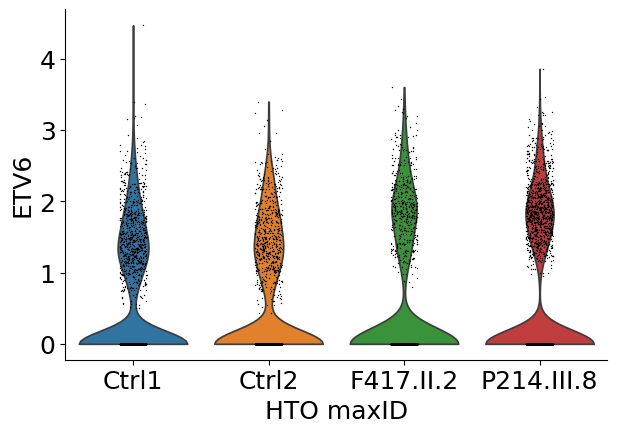

In [40]:
# check on-target effect on ETV6 GEX
sc.pl.violin(
    adata_etv6,
    keys=['ETV6'],
    groupby='HTO_maxID',
)


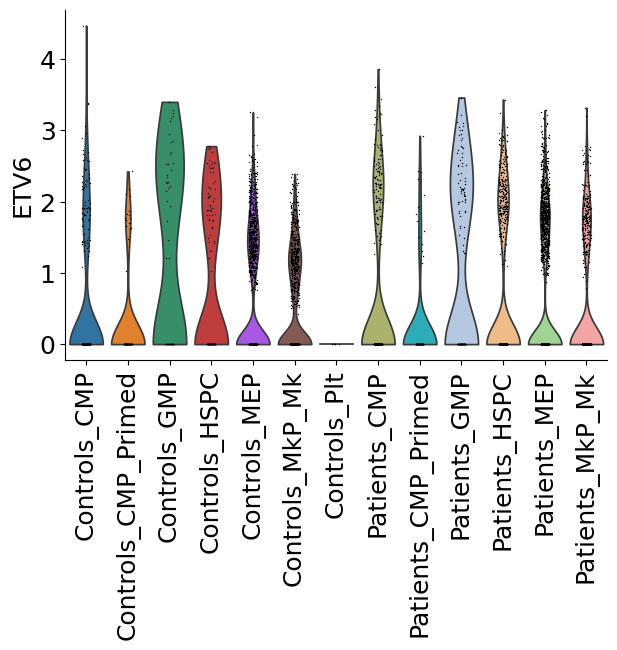

In [41]:
sc.pl.violin(
    adata_etv6,
    keys=['ETV6'],
    groupby='celltypes_ETV6status',
    rotation=90,
)


In [42]:
adata_etv6

AnnData object with n_obs × n_vars = 7715 × 4890
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'MULTI_ID', 'MULTI_classification', 'barcode', 'assignment', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'souporcell_classif', 'HT0_souporcell_classif', 'HT0_souporcell_classif_final', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'individuals', 'ETV6status', 'sample', 'RNA_snn_res.1.5', 'RNA_snn_res.3', 'RNA_snn_res.4', 'celltypes', 'nCount_AUC', 'nFeature_AUC', 'nCount_BIN', 'nFeature_BIN', 'celltypes_ETV6status', 'delta_logprob', 'soupor_cluster_from_hs', 'pt_ctrl_label', 'n_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_cells'
    uns: 'ETV6status_colors', 'HTO_classification.global_colors', 'HTO_

In [43]:

# Regress out library size & mito %, then scale
# sc.pp.regress_out(adata_etv6, ['nCount_RNA'])
# sc.pp.scale(adata_etv6, max_value=10)

# --- 2) PCA and quick visual checks ---
sc.tl.pca(adata_etv6, svd_solver='arpack')


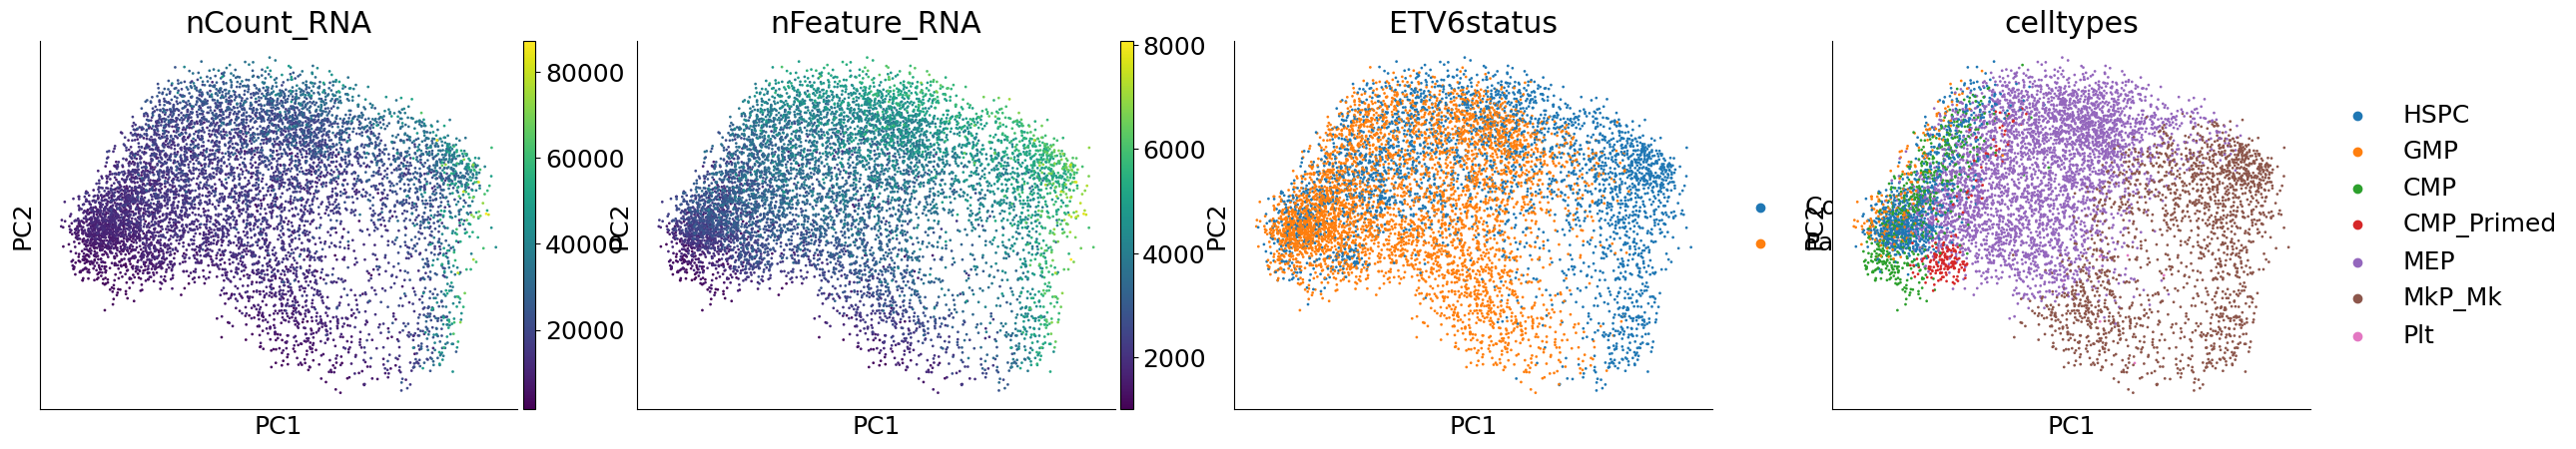

|r| vs nCount_RNA (first 10 PCs):
 PC1     0.623
PC2     0.396
PC3     0.077
PC4     0.198
PC5     0.190
PC6     0.130
PC7     0.218
PC8     0.089
PC9     0.079
PC10    0.001
dtype: float64
|r| vs nFeature_RNA (first 10 PCs):
 PC1     0.683
PC2     0.503
PC3     0.021
PC4     0.164
PC5     0.199
PC6     0.137
PC7     0.289
PC8     0.122
PC9     0.065
PC10    0.026
dtype: float64


In [ ]:
# explore read depth effect
sc.pl.pca(adata_etv6, color=['nCount_RNA', 'nFeature_RNA', 'ETV6status', 'celltypes'])

# --- 3) Quantify correlation of PCs with QC metrics ---
pcs = pd.DataFrame(adata_etv6.obsm['X_pca'], index=adata_etv6.obs_names,
                   columns=[f'PC{i+1}' for i in range(adata_etv6.obsm['X_pca'].shape[1])])
qc = adata_etv6.obs[['nCount_RNA', 'nFeature_RNA',]].copy()

def corr_to_qc(pcs_df, qc_series, top_k=10, label='total_counts'):
    r = pcs_df.iloc[:, :top_k].apply(lambda pc: pc.corr(qc_series))
    print(f'|r| vs {label} (first {top_k} PCs):\n', r.abs().round(3))
    return r

r_counts  = corr_to_qc(pcs, qc['nCount_RNA'], top_k=10, label='nCount_RNA')
r_genes   = corr_to_qc(pcs, qc['nFeature_RNA'], top_k=10, label='nFeature_RNA')

In [45]:
celltypes = [
    'LT-HSC', 'ST-HSC', 'MPP',
    'LMPP', 'PreProB', 'Small_Pre_B', 'Immature_B', 'Pro_B', 'Cycling_Pro_B', 'Large_Pre_B', 'pDC', 
    'MEMP', 'MK', 'Early_Ery', 'Late_Ery', 'BaEoMa',
    'GMP', 'DC_pre', 'Mono_pre', 'Macrophage'
]


In [46]:
adata_etv6_megK = adata_etv6[adata_etv6.obs['celltypes'].isin(['MkP_Mk'])].copy()
adata_etv6_memp_megK = adata_etv6[adata_etv6.obs['celltypes'].isin(['MEP', 'MkP_Mk'])].copy()
adata_pert_megK = adata_all[adata_all.obs['celltype_v2'].isin(['MK'])].copy()

/nfs/team361/cytomeister/.cytomeister/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


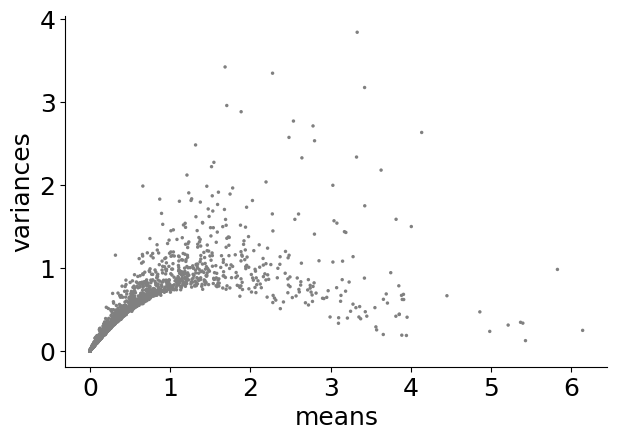

In [47]:
# use scanpy to plot gene mean variance relationship
adata_etv6_megK.var['means'] = adata_etv6_megK.X.mean(axis=0).A1
adata_etv6_megK.var['variances'] = np.var(adata_etv6_megK.X.toarray(), axis=0)
sc.pl.scatter(adata_etv6_megK, x='means', y='variances')

In [48]:
adata_etv6_megK

AnnData object with n_obs × n_vars = 1842 × 4890
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'MULTI_ID', 'MULTI_classification', 'barcode', 'assignment', 'log_prob_singleton', 'log_prob_doublet', 'cluster0', 'cluster1', 'cluster2', 'cluster3', 'souporcell_classif', 'HT0_souporcell_classif', 'HT0_souporcell_classif_final', 'percent.mt', 'RNA_snn_res.0.8', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'individuals', 'ETV6status', 'sample', 'RNA_snn_res.1.5', 'RNA_snn_res.3', 'RNA_snn_res.4', 'celltypes', 'nCount_AUC', 'nFeature_AUC', 'nCount_BIN', 'nFeature_BIN', 'celltypes_ETV6status', 'delta_logprob', 'soupor_cluster_from_hs', 'pt_ctrl_label', 'n_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'n_cells', 'means', 'variances'
    uns: 'ETV6status_colors', 'HTO_classification

In [49]:
adata_etv6_megK.obs['celltypes_ETV6status']

D6_CCTACACCAGTTAACC     Controls_MkP_Mk
D6_GGTGCGTAGGCATGTG     Controls_MkP_Mk
D6_TGCCCTACACCGGAAA     Controls_MkP_Mk
D6_AGTGGGAGTCCGAATT     Patients_MkP_Mk
D6_CACACCTTCTTGGGTA     Patients_MkP_Mk
                             ...       
D11_TTTGGTTGTATGGTTC    Patients_MkP_Mk
D11_TTTGTCACAGCGATCC    Patients_MkP_Mk
D11_TTTGTCACATCGGGTC    Patients_MkP_Mk
D11_TTTGTCAGTAAGGATT    Patients_MkP_Mk
D11_TTTGTCAGTTCGGGCT    Controls_MkP_Mk
Name: celltypes_ETV6status, Length: 1842, dtype: category
Categories (2, object): ['Controls_MkP_Mk', 'Patients_MkP_Mk']

In [50]:
adata_etv6_megK.obs['ETV6status'].value_counts()

ETV6status
Controls    1104
Patients     738
Name: count, dtype: int64

In [51]:
adata_etv6_memp_megK.obs['ETV6status'].value_counts()

ETV6status
Patients    3135
Controls    2735
Name: count, dtype: int64

###  Supplementary plots

In [52]:
p_zip = pooch.retrieve(
    "https://www.dropbox.com/s/3dby3bjsaf5arrw/cell_cycle_vignette_files.zip?dl=1",
    known_hash="sha256:6557fe2a2761d1550d41edf61b26c6d5ec9b42b4933d56c3161164a595f145ab",
    path="../data",
)

In [53]:
with zipfile.ZipFile(p_zip, "r") as f_zip:
    cell_cycle_genes = zipfile.Path(f_zip, "regev_lab_cell_cycle_genes.txt").read_text().splitlines()

In [54]:
s_genes = [x for x in cell_cycle_genes[:43] if x in adata_all.var_names]
g2m_genes = [x for x in cell_cycle_genes[43:] if x in adata_all.var_names]
cell_cycle_genes = [*s_genes, *g2m_genes]

In [55]:
# score cycling cells in healthy
sc.tl.score_genes_cell_cycle(adata_etv6_megK, s_genes=s_genes, g2m_genes=g2m_genes)
sc.tl.score_genes_cell_cycle(adata_pert_megK, s_genes=s_genes, g2m_genes=g2m_genes)

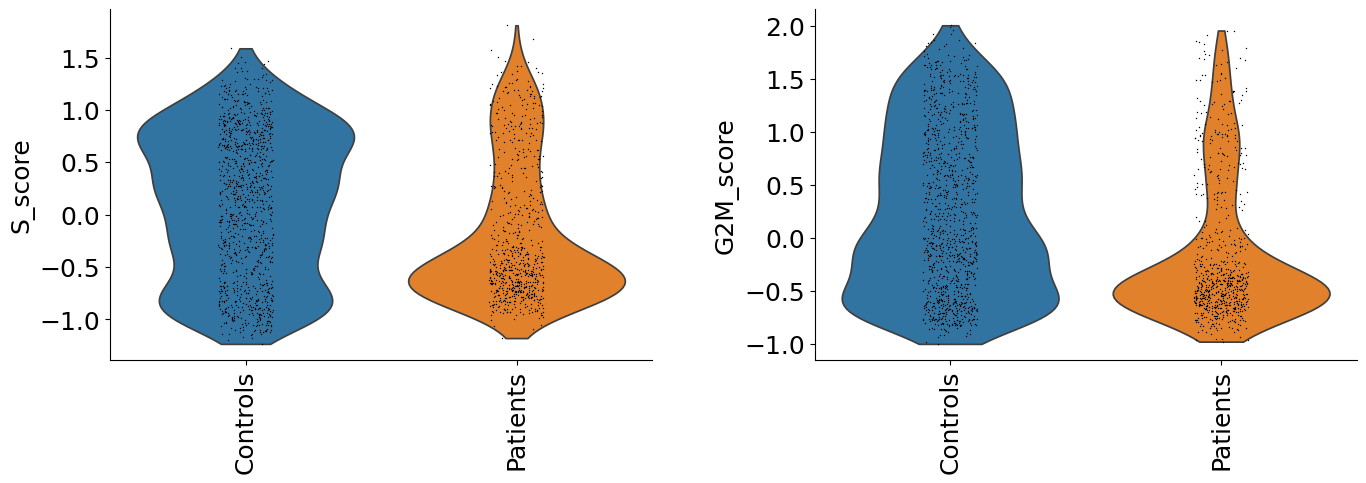

In [56]:
# plot cell cycle scores
sc.pl.violin(
    adata_etv6_megK,
    keys=['S_score', 'G2M_score'],
    groupby='ETV6status',
    rotation=90,
)

In [57]:
adata_all

AnnData object with n_obs × n_vars = 56028 × 4890
    obs: 'sex', 'phase', 'tissue', 'celltype_v2', 'diff_state', 'cell_idx', 'perturb_mode'
    uns: 'log1p'
    obsm: 'mean_cos_similarity', 'perturbed_cls', 'true_cls'
    layers: 'pred_counts', 'true_counts'

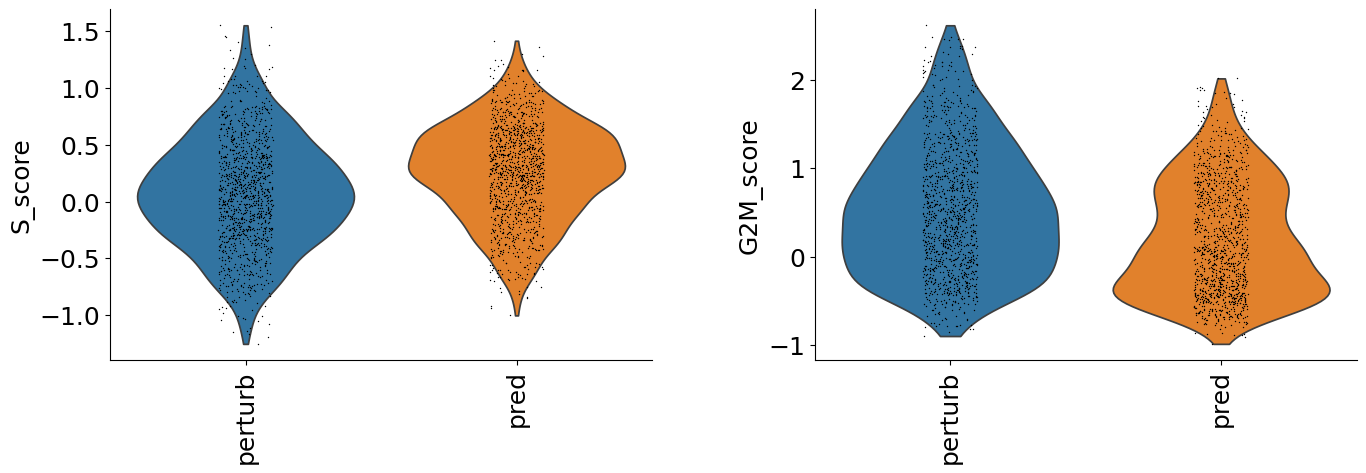

In [58]:
# plot cell cycle scores
sc.pl.violin(
    adata_pert_megK,
    keys=['S_score', 'G2M_score'],
    groupby='perturb_mode',
    rotation=90,
)

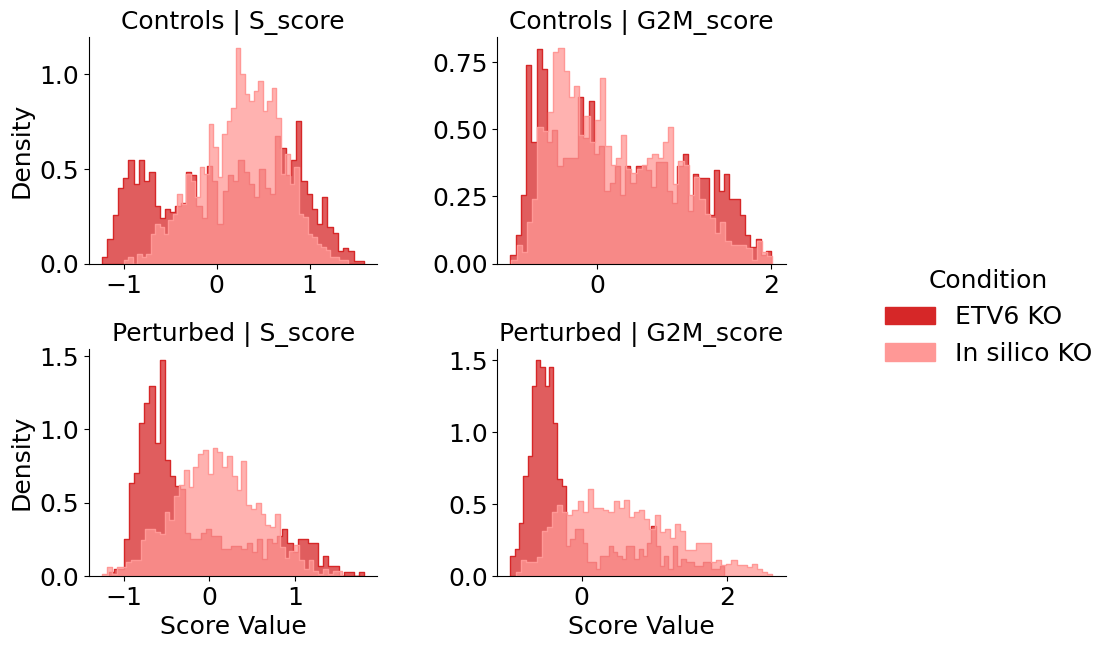

In [59]:
# Subset data
adata_etv6_ctrl = adata_etv6_megK[adata_etv6_megK.obs['ETV6status'] == 'Controls'].copy()
adata_etv6_pat  = adata_etv6_megK[adata_etv6_megK.obs['ETV6status'] == 'Patients'].copy()
adata_etv6_pred = adata_pert_megK[adata_pert_megK.obs['perturb_mode'] == 'pred'].copy()
adata_etv6_pert = adata_pert_megK[adata_pert_megK.obs['perturb_mode'] == 'perturb'].copy()

# Combine all into one dataframe
plot_df = pd.DataFrame({
    'S_score': np.concatenate([
        adata_etv6_ctrl.obs['S_score'].values,
        adata_etv6_pred.obs['S_score'].values,
        adata_etv6_pat.obs['S_score'].values,
        adata_etv6_pert.obs['S_score'].values
    ]),
    'G2M_score': np.concatenate([
        adata_etv6_ctrl.obs['G2M_score'].values,
        adata_etv6_pred.obs['G2M_score'].values,
        adata_etv6_pat.obs['G2M_score'].values,
        adata_etv6_pert.obs['G2M_score'].values
    ]),
    'group': (
        ['Controls'] * adata_etv6_ctrl.shape[0] +
        ['Predicted'] * adata_etv6_pred.shape[0] +
        ['Patients'] * adata_etv6_pat.shape[0] +
        ['Perturbed'] * adata_etv6_pert.shape[0]
    )
})

# Define facet rows
plot_df['row'] = plot_df['group'].map({
    'Controls': 'Controls',
    'Predicted': 'Controls',
    'Patients': 'Perturbed',
    'Perturbed': 'Perturbed'
})

# Melt for long format (so we can facet by score)
plot_df_long = plot_df.melt(
    id_vars=['group', 'row'],
    value_vars=['S_score', 'G2M_score'],
    var_name='score_type',
    value_name='score_value'
)

palette = {
    'Controls': '#d62728',   # blue
    'Patients': '#d62728',   # same blue
    'Predicted': '#ff9896',  # orange
    'Perturbed': '#ff9896'   # same orange
}

# Create FacetGrid: 2 rows (ETV6, Pert) × 2 cols (S_score, G2M_score)
g = sns.FacetGrid(
    plot_df_long,
    row='row',
    col='score_type',
    hue='group',
    palette=palette,
    sharex=False,
    sharey=False,
    height=3.5,
    aspect=1.2,
)

# Map histograms
g.map_dataframe(
    sns.histplot,
    x='score_value',
    element='step',
    stat='density',
    common_norm=False,
    bins=50
)

g.add_legend(title='Group')
g._legend.remove()  # or g.add_legend = lambda *args, **kwargs: None

# add legend to the figure
custom_handles = [
    mpatches.Patch(color='#d62728', label='ETV6 KO'),
    mpatches.Patch(color='#ff9896', label='In silico KO')
]


g.fig.legend(
    handles=custom_handles,
    title='Condition',
    loc='center right',       # you can use 'upper right', 'lower right', etc.
    bbox_to_anchor=(1.1, 0.5),  # position outside the grid
    frameon=False
)
g.set_axis_labels("Score Value", "Density")
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
# g.fig.suptitle('Cell Cycle Score Distributions across ETV6 and Perturb Conditions')
plt.savefig(
    f'{res_dir}/etv6_cell_cycle_score_invitro_insilico_distributions.pdf',
    dpi=300,
    bbox_inches='tight'
)

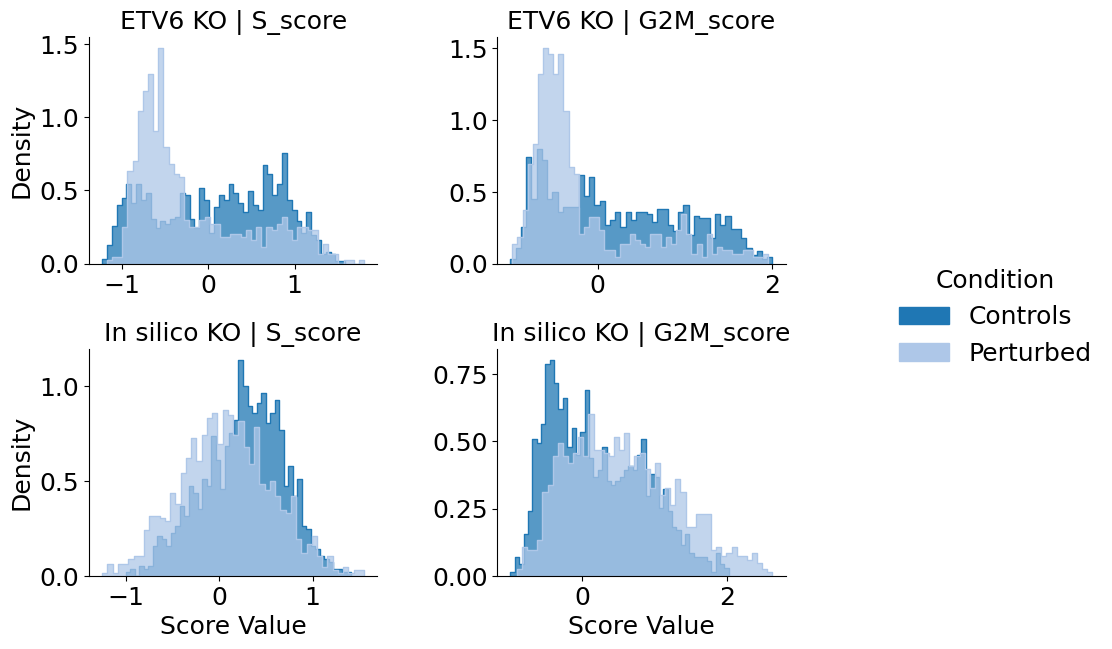

In [60]:
# Define facet rows
plot_df['row'] = plot_df['group'].map({
    'Controls': 'ETV6 KO',
    'Predicted': 'In silico KO',
    'Patients': 'ETV6 KO',
    'Perturbed': 'In silico KO'
})

# Melt for long format (so we can facet by score)
plot_df_long = plot_df.melt(
    id_vars=['group', 'row'],
    value_vars=['S_score', 'G2M_score'],
    var_name='score_type',
    value_name='score_value'
)

palette = {
    'Controls': '#1f77b4',   # blue
    'Patients': '#aec7e8',   # same blue
    'Predicted': '#1f77b4',  # orange
    'Perturbed': '#aec7e8'   # same orange
}

# Create FacetGrid: 2 rows (ETV6, Pert) × 2 cols (S_score, G2M_score)
g = sns.FacetGrid(
    plot_df_long,
    row='row',
    col='score_type',
    hue='group',
    palette=palette,
    sharex=False,
    sharey=False,
    height=3.5,
    aspect=1.2,
)

# Map histograms
g.map_dataframe(
    sns.histplot,
    x='score_value',
    element='step',
    stat='density',
    common_norm=False,
    bins=50
)

g.add_legend(title='Group')
g._legend.remove()

# add legend to the figure
custom_handles = [
    mpatches.Patch(color='#1f77b4', label='Controls'),
    mpatches.Patch(color='#aec7e8', label='Perturbed')
]

g.fig.legend(
    handles=custom_handles,
    title='Condition',
    loc='center right',       # you can use 'upper right', 'lower right', etc.
    bbox_to_anchor=(1.1, 0.5),  # position outside the grid
    frameon=False
)
g.set_axis_labels("Score Value", "Density")
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
# g.fig.suptitle('Cell Cycle Score Distributions across ETV6 and Perturb Conditions')

plt.savefig(
    f'{res_dir}/etv6_cell_cycle_score_control_perturbed_distributions.pdf',
    dpi=300,
    bbox_inches='tight'
)

###  Supplementary plots

In [61]:
bad = (
    ((adata_etv6_megK.obs["ETV6status"] == "Controls") & (adata_etv6_megK.obs["HTO_maxID"].isin(["P214.III.8", "F417.II.2"]))) |
    ((adata_etv6_megK.obs["ETV6status"] == "Patients") & (adata_etv6_megK.obs["HTO_maxID"].isin(["Ctrl1", "Ctrl2"])))
)

keep = ~bad

print("Dropping", bad.sum(), "cells")

adata_etv6_megK = adata_etv6_megK[keep].copy()

Dropping 27 cells


/tmp/ipykernel_1722997/3109019456.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


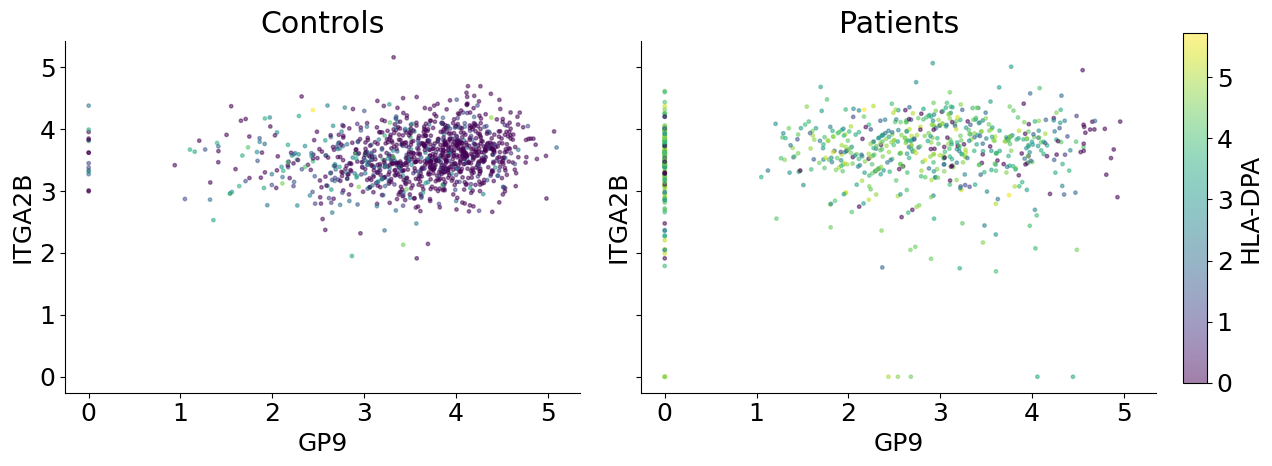

In [62]:
# adata_etv6_megK: your AnnData
group_col = "ETV6status"   # change if your column name differs

genes = ["GP9", "ITGA2B", "HLA-DRA"]
X = adata_etv6_megK[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, columns=genes, index=adata_etv6_megK.obs_names)
df[group_col] = adata_etv6_megK.obs[group_col].astype(str).values

groups = list(df[group_col].unique())

fig, axes = plt.subplots(1, len(groups), figsize=(6*len(groups), 5), sharex=True, sharey=True)
if len(groups) == 1:
    axes = [axes]

for ax, g in zip(axes, groups):
    sub = df[df[group_col] == g]
    sca = ax.scatter(sub["GP9"], sub["ITGA2B"], c=sub["HLA-DRA"], s=6, alpha=0.5)
    ax.set_title(g)
    ax.set_xlabel("GP9")
    ax.set_ylabel("ITGA2B")

cax = fig.add_axes([1., 0.2, 0.02, 0.7])
cbar = fig.colorbar(sca, cax=cax)
cbar.set_label("HLA-DPA")
plt.tight_layout()
# save figure
plt.savefig(
    f'{res_dir}/etv6_mk_marker_expression_ETV6status.pdf',
    dpi=300,
    bbox_inches='tight'
)

In [63]:
# GP9 expression (use the same layer you normally plot from)
gp9 = adata_etv6_megK[:, "GP9"].X
gp9 = gp9.A1 if hasattr(gp9, "A1") else gp9.toarray().flatten()

adata_etv6_megK.obs["GP9_status"] = np.where(gp9 > 0, "GP9+", "GP9−")

adata_etv6_megK.obs["group_gp9"] = (
    adata_etv6_megK.obs["pt_ctrl_label"].astype(str)
    + " · "
    + adata_etv6_megK.obs["GP9_status"]
)

# enforce plotting order
adata_etv6_megK.obs["group_gp9"] = adata_etv6_megK.obs["group_gp9"].astype("category")
adata_etv6_megK.obs["group_gp9"].cat.reorder_categories(
    ["control · GP9+", "control · GP9−", "patient · GP9+", "patient · GP9−"],
    
)

D6_CCTACACCAGTTAACC     control · GP9+
D6_GGTGCGTAGGCATGTG     control · GP9+
D6_TGCCCTACACCGGAAA     control · GP9+
D6_AGTGGGAGTCCGAATT     patient · GP9+
D6_CACACCTTCTTGGGTA     patient · GP9+
                             ...      
D11_TTTGGTTGTATGGTTC    patient · GP9−
D11_TTTGTCACAGCGATCC    patient · GP9+
D11_TTTGTCACATCGGGTC    patient · GP9+
D11_TTTGTCAGTAAGGATT    patient · GP9+
D11_TTTGTCAGTTCGGGCT    control · GP9+
Name: group_gp9, Length: 1815, dtype: category
Categories (4, object): ['control · GP9+', 'control · GP9−', 'patient · GP9+', 'patient · GP9−']

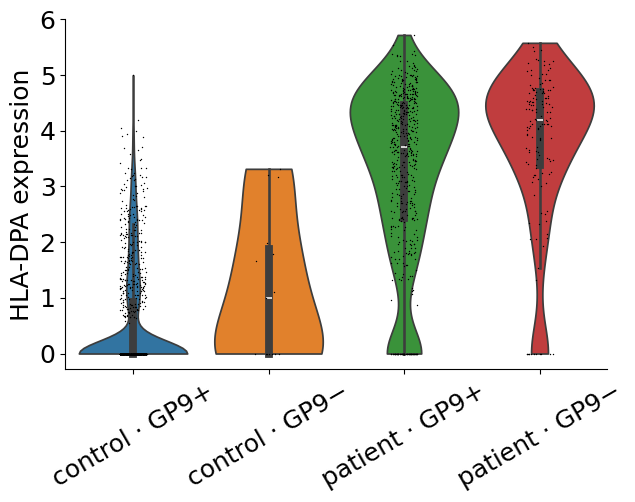

In [81]:
sc.pl.violin(
    adata_etv6_megK,
    keys="HLA-DRA",
    groupby="group_gp9",
    stripplot=True,     # cleaner for supplement
    inner="box",         # median + IQR
    rotation=30,
    ylabel="HLA-DPA expression",
    show=False
)
# save plot
plt.savefig(
    f'{res_dir}/etv6_mk_marker_gp9_gating.pdf',
    dpi=300,
    bbox_inches='tight'
)

In [65]:
import numpy as np
import pandas as pd

group_col = "ETV6status"

genes = ["ITGA2B","GP9","LST1","TYROBP","HLA-DRA","CD74"]
X = adata_etv6_megK[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

df = pd.DataFrame(X, columns=genes, index=adata_etv6_megK.obs_names)
df[group_col] = adata_etv6_megK.obs[group_col].astype(str).values

# Tune these thresholds based on your distributions
df["MK_lineage"] = (df["ITGA2B"] > 1.0) & (df["GP9"] > 1.0)

# stricter APC filter (AND)
df["APC_like_strict"] = (df["LST1"] > 1.0) & (df["TYROBP"] > 1.0)

df["MK_clean_ITGA2B_GP9"] = df["MK_lineage"] & (~df["APC_like_strict"])

# Quick check: does the MHC-II signal persist?
summary = df.groupby(group_col).agg(
    n=("ITGA2B","size"),
    frac_MK_clean=("MK_clean_ITGA2B_GP9","mean"),
    frac_HLADRA_high=( "HLA-DRA", lambda s: np.mean(s > 1.0)),
    frac_MKclean_and_HLADRA=("MK_clean_ITGA2B_GP9",
                            lambda s: np.mean(s & (df.loc[s.index,"HLA-DRA"] > 1.0))),
)

summary["P(HLA-DRA_high | MK_clean)"] = summary["frac_MKclean_and_HLADRA"] / summary["frac_MK_clean"]
print(summary)


               n  frac_MK_clean  frac_HLADRA_high  frac_MKclean_and_HLADRA  \
ETV6status                                                                   
Controls    1101       0.289737          0.244323                 0.048138   
Patients     714       0.180672          0.889356                 0.141457   

            P(HLA-DRA_high | MK_clean)  
ETV6status                              
Controls                      0.166144  
Patients                      0.782946  


In [66]:
genes = ["ITGA2B","GP9","LST1","TYROBP"]
X = adata_etv6_megK[:, genes].X
if not isinstance(X, np.ndarray):
    X = X.toarray()

itga2b, gp9, lst1, tyrobp = X.T

adata_etv6_megK.obs["MK_lineage"] = (itga2b > 1.0) & (gp9 > 1.0)
adata_etv6_megK.obs["APC_like_strict"] = (lst1 > 1.0) & (tyrobp > 1.0)
adata_etv6_megK.obs["MK_clean"] = adata_etv6_megK.obs["MK_lineage"] & (~adata_etv6_megK.obs["APC_like_strict"])


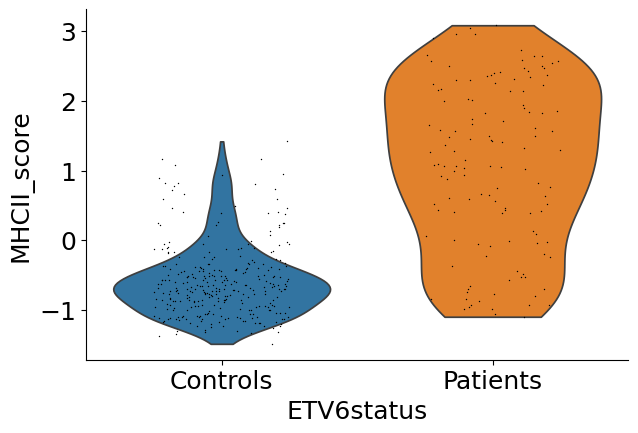

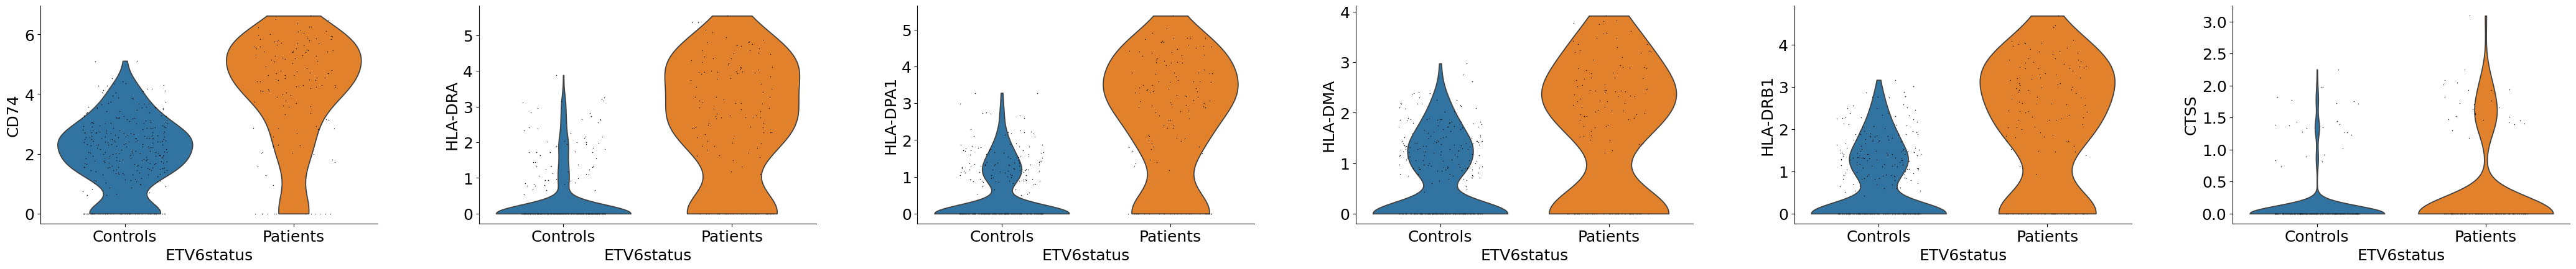

In [82]:
# score genes CD74, HLA-DRA, HLA-DPA1, HLA-DMA/DMB, CTSS
adata_etv6_megK_clean = adata_etv6_megK[adata_etv6_megK.obs['MK_clean'] == True].copy()
hla_genes = ['CD74',  'HLA-DRA', 'HLA-DPA1', 'HLA-DMA', 'HLA-DRB1', 'CTSS']
sc.tl.score_genes(adata_etv6_megK_clean, hla_genes, score_name='MHCII_score')
sc.pl.violin(
    adata_etv6_megK_clean,
    keys=['MHCII_score'],
    groupby='ETV6status',
    stripplot=True,
    jitter=0.25,
    show=False
)
plt.savefig(
    f'{res_dir}/etv6_mhcii_score_violin.pdf',
    dpi=300,
    bbox_inches='tight'
)
sc.pl.violin(
    adata_etv6_megK_clean,
    hla_genes,
    groupby='ETV6status',
    stripplot=True,
    jitter=0.25,
    show=False
)
plt.savefig(
    f'{res_dir}/etv6_mhcii_score_genes_violin.pdf',
    dpi=300,
    bbox_inches='tight'
)

In [68]:
import scanpy as sc

mk_maturation = ["PF4","PPBP","NFE2","VWF","TUBB1","ITGA2B", "GP9", "GP1BA"]
apc_myeloid   = ["LST1","TYROBP","FCER1A","AIF1","CTSS"]
ifn_response  = ["STAT1","IRF1","ISG15","IFIT1","IFIT3","MX1","OAS1"]

# keep only genes present
def present(adata, genes): 
    return [g for g in genes if g in adata.var_names]

sc.tl.score_genes(adata_etv6_megK_clean, present(adata_etv6_megK_clean, mk_maturation), score_name="MK_maturation_score")
sc.tl.score_genes(adata_etv6_megK_clean, present(adata_etv6_megK_clean, apc_myeloid),   score_name="APC_myeloid_score")
sc.tl.score_genes(adata_etv6_megK_clean, present(adata_etv6_megK_clean, ifn_response),  score_name="IFN_score")


/tmp/ipykernel_1722997/105374582.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


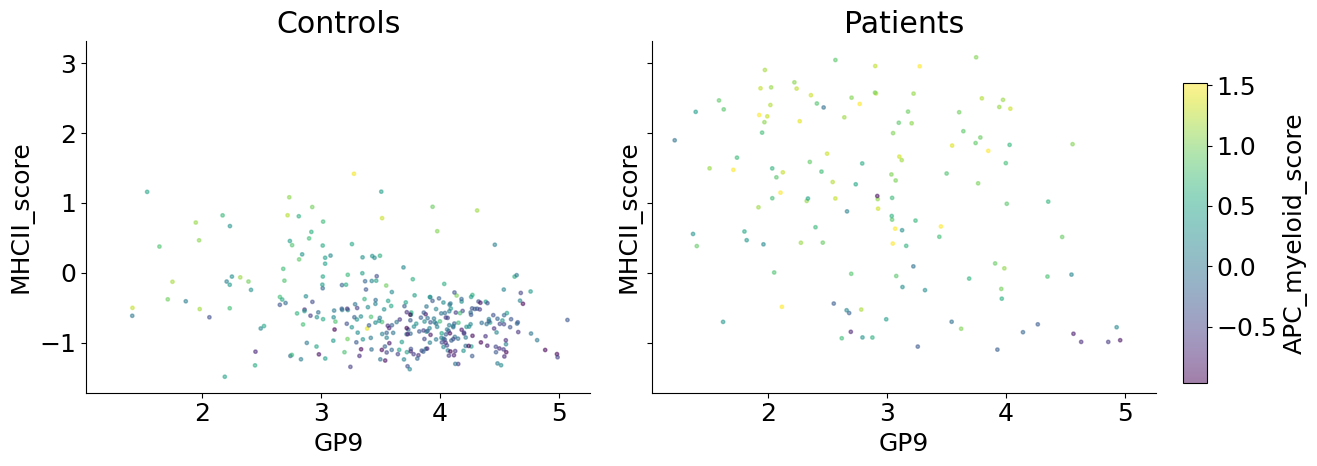

In [69]:
import numpy as np
import matplotlib.pyplot as plt


x_gene = "GP9"       # or "ITGA2B"
y_col  = "MHCII_score"
c_col  = "APC_myeloid_score"
group_col = "ETV6status"

# pull x gene expression vector
x = adata_etv6_megK_clean[:, [x_gene]].X
if not isinstance(x, np.ndarray):
    x = x.toarray()
x = x[:, 0]

y = adata_etv6_megK_clean.obs[y_col].astype(float).values
c = adata_etv6_megK_clean.obs[c_col].astype(float).values
groups = adata_etv6_megK_clean.obs[group_col].astype(str).unique().tolist()

# consistent color scale across facets
vmin, vmax = np.quantile(c, 0.02), np.quantile(c, 0.98)

fig, axes = plt.subplots(1, len(groups), figsize=(6*len(groups), 5), sharex=True, sharey=True)
if len(groups) == 1:
    axes = [axes]

sc_last = None
for ax, g in zip(axes, groups):
    m = (adata_etv6_megK_clean.obs[group_col].astype(str).values == g)
    sc_last = ax.scatter(x[m], y[m], c=c[m], s=6, alpha=0.5, vmin=vmin, vmax=vmax, cmap="viridis")
    ax.set_title(g)
    ax.set_xlabel(x_gene)
    ax.set_ylabel(y_col)

# colorbar outside
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([1.0, 0.2, 0.02, 0.6])
cbar = fig.colorbar(sc_last, cax=cax)
cbar.set_label(c_col)

plt.tight_layout()
plt.savefig(
    f'{res_dir}/etv6_mhcii_score_gp9_scatter.pdf',
    dpi=300,
    bbox_inches='tight'
)

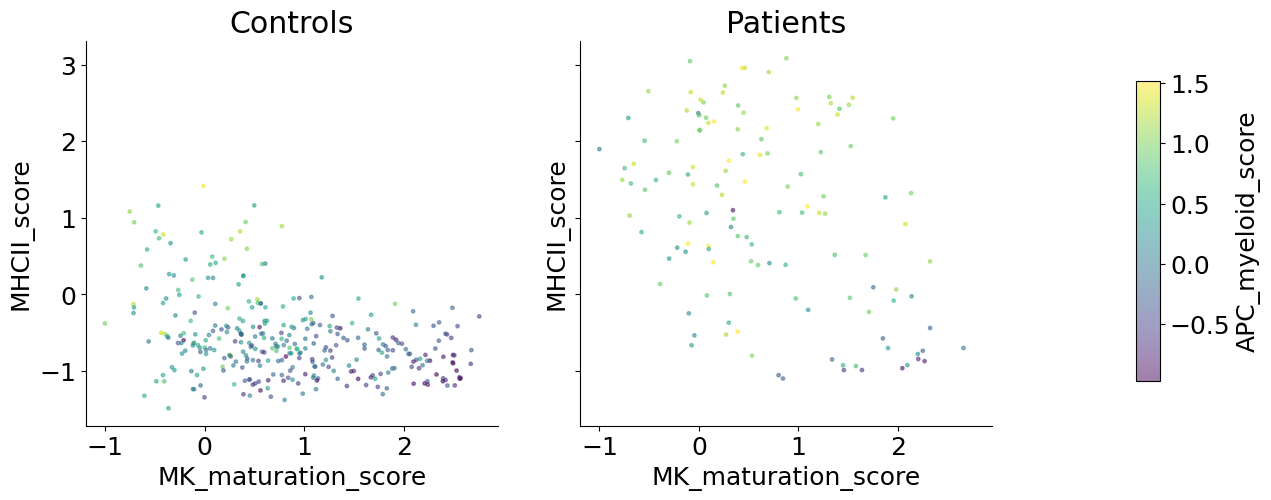

In [70]:
import numpy as np
import matplotlib.pyplot as plt


x_gene = "MK_maturation_score"       # or "ITGA2B"
y_col  = "MHCII_score"
c_col  = "APC_myeloid_score"
group_col = "ETV6status"

# # pull x gene expression vector
# x = adata_etv6_megK_clean[:, [x_gene]].X
# if not isinstance(x, np.ndarray):
#     x = x.toarray()
# x = x[:, 0]
x = adata_etv6_megK_clean.obs[x_gene].astype(float).values
y = adata_etv6_megK_clean.obs[y_col].astype(float).values
c = adata_etv6_megK_clean.obs[c_col].astype(float).values
groups = adata_etv6_megK_clean.obs[group_col].astype(str).unique().tolist()

# consistent color scale across facets
vmin, vmax = np.quantile(c, 0.02), np.quantile(c, 0.98)

fig, axes = plt.subplots(1, len(groups), figsize=(6*len(groups), 5), sharex=True, sharey=True)
if len(groups) == 1:
    axes = [axes]

sc_last = None
for ax, g in zip(axes, groups):
    m = (adata_etv6_megK_clean.obs[group_col].astype(str).values == g)
    sc_last = ax.scatter(x[m], y[m], c=c[m], s=6, alpha=0.5, vmin=vmin, vmax=vmax, cmap="viridis")
    ax.set_title(g)
    ax.set_xlabel(x_gene)
    ax.set_ylabel(y_col)

# colorbar outside
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([1.0, 0.2, 0.02, 0.6])
cbar = fig.colorbar(sc_last, cax=cax)
cbar.set_label(c_col)

plt.savefig(
    f'{res_dir}/etv6_mhcii_score_mkmaturation_scatter.pdf',
    dpi=300,
    bbox_inches='tight'
)


Mann–Whitney U (Wilcoxon rank-sum): U=9381.0, p=1.861e-19
Rank-biserial effect size (Patients higher positive): r_rb=0.544
n Controls=319, n Patients=129


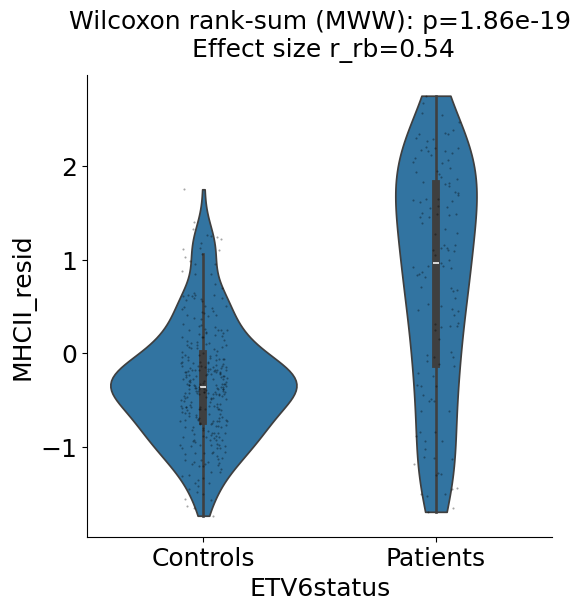

In [71]:
group_col = "ETV6status"     # "Controls" vs "Patients"

score_col = "MHCII_score"    # your module score in .obs

qc_covs = ["nCount_RNA", "nFeature_RNA", "percent.mt"]  # adjust if needed



# ---- Build dataframe ----
df = adata_etv6_megK_clean.obs[[group_col, score_col] + qc_covs].copy()
df[group_col] = df[group_col].astype(str)
df[score_col] = df[score_col].astype(float)
for c in qc_covs:
    df[c] = df[c].astype(float)

# ---- Residualize score_col on qc_covs (linear regression) ----
X = df[qc_covs].values
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)  # standardize covariates
X = np.column_stack([np.ones(X.shape[0]), X])      # intercept

y = df[score_col].values
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
df["MHCII_resid"] = y - (X @ beta)

# ---- Mann–Whitney U test (Wilcoxon rank-sum) ----
controls = df.loc[df[group_col] == "Controls", "MHCII_resid"].values
patients = df.loc[df[group_col] == "Patients", "MHCII_resid"].values

# two-sided test
u_stat, p_val = mannwhitneyu(controls, patients, alternative="two-sided")

# Effect size: rank-biserial correlation (equivalent to Cliff's delta for two groups)
n1, n2 = len(controls), len(patients)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)  # sign depends on ordering
# Make it "Patients higher is positive"
# If patients tend to be higher, U (controls vs patients) will be smaller and rank_biserial will be positive.
# If not, flip sign for interpretability:
if np.median(patients) < np.median(controls):
    rank_biserial *= -1

print(f"Mann–Whitney U (Wilcoxon rank-sum): U={u_stat:.1f}, p={p_val:.3e}")
print(f"Rank-biserial effect size (Patients higher positive): r_rb={rank_biserial:.3f}")
print(f"n Controls={n1}, n Patients={n2}")

# ---- Plot with annotation ----
plt.figure(figsize=(6, 6))
ax = sns.violinplot(data=df, x=group_col, y="MHCII_resid", cut=0, inner="box")
sns.stripplot(data=df, x=group_col, y="MHCII_resid", color="k", size=1.5, alpha=0.35)

# title = "MHCII residuals (MK_clean)\nregressed: " + ", ".join(qc_covs)
# ax.set_title(title)
ax.set_xlabel(group_col)
ax.set_ylabel("MHCII_resid")

# add p-value text
ymax = df["MHCII_resid"].max()
ymin = df["MHCII_resid"].min()
ypos = ymax + 0.08 * (ymax - ymin)

ax.text(
    0.5, ypos,
    f"Wilcoxon rank-sum (MWW): p={p_val:.2e}\n Effect size r_rb={rank_biserial:.2f}",
    ha="center", va="bottom"
)

plt.savefig(
    f'{res_dir}/etv6_mhcii_score_resid_violin.pdf',
    dpi=300,
    bbox_inches='tight'
)


In [72]:
obs = adata_etv6_megK.obs.copy()
obs["MHCII_resid"] = df["MHCII_resid"]
# keep only the columns we need, and force them to plain strings
tmp = obs[["ETV6status", "HTO_maxID", "MHCII_resid"]].copy()
tmp["ETV6status"] = tmp["ETV6status"].astype(str)
tmp["HTO_maxID"]  = tmp["HTO_maxID"].astype(str)

donor_df = (
    tmp.groupby(["ETV6status", "HTO_maxID"])["MHCII_resid"]
       .median()
       .reset_index(name="MHCII_resid_median")
)

donor_df


,ETV6status,HTO_maxID,MHCII_resid_median
0,Controls,Ctrl1,-0.542633
1,Controls,Ctrl2,-0.177904
2,Patients,F417.II.2,0.689642
3,Patients,P214.III.8,1.287642


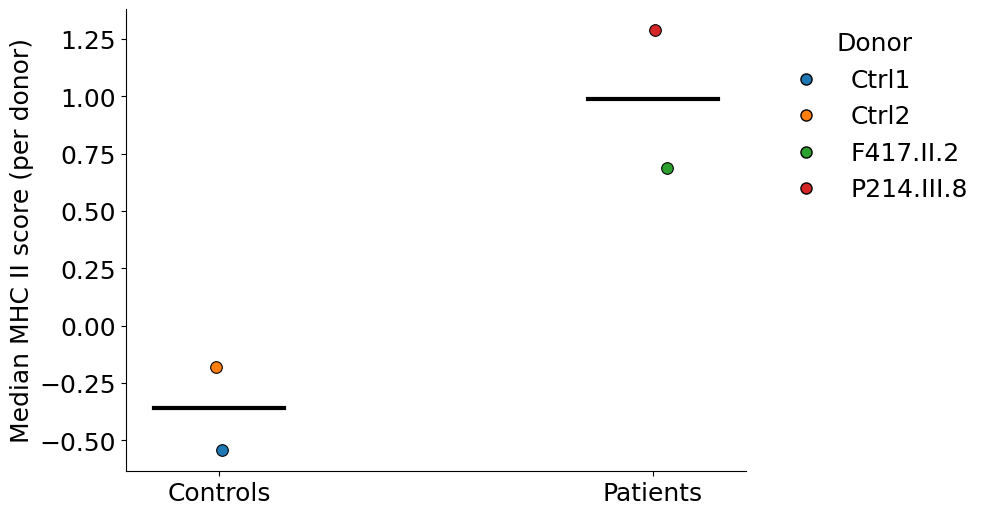

In [73]:
order = ["Controls", "Patients"]
xpos = {g:i for i,g in enumerate(order)}

# Make a fixed donor->color map (choose any colors you like)
donors = donor_df["HTO_maxID"].unique().tolist()
cmap = plt.get_cmap("tab10")
donor2color = {d: cmap(i % 10) for i, d in enumerate(donors)}

fig, ax = plt.subplots(figsize=(8,6))
rng = np.random.default_rng(0)

# plot donor dots + group mean lines
for g in order:
    dsub = donor_df[donor_df["ETV6status"] == g].copy()
    x = np.full(len(dsub), xpos[g], dtype=float) + rng.normal(0, 0.05, size=len(dsub))

    for xi, (_, r) in zip(x, dsub.iterrows()):
        ax.scatter(
            xi, r["MHCII_resid_median"],
            s=70,
            color=donor2color[r["HTO_maxID"]],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )

    # mean line of donor medians for the group (in neutral color)
    ymean = dsub["MHCII_resid_median"].mean()
    ax.plot([xpos[g]-0.15, xpos[g]+0.15], [ymean, ymean],
            lw=3, color="black", zorder=2)

# legend: create handles using the same donor2color map
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=donor2color[d],
               markeredgecolor='black', markersize=8, label=d)
    for d in donors
]
ax.legend(handles=handles, title="Donor", bbox_to_anchor=(1.02, 1),
          loc="upper left", frameon=False)

ax.set_xticks([xpos[g] for g in order])
ax.set_xticklabels(order)
ax.set_ylabel("Median MHC II score (per donor)")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.savefig(
    f'{res_dir}/etv6_mhcii_score_repli.pdf',
    dpi=300,
    bbox_inches='tight'
)

Mann–Whitney U (Wilcoxon rank-sum): U=28698.0, p=5.931e-11
Rank-biserial effect size (Patients higher positive): r_rb=0.395
n Controls=319, n Patients=129


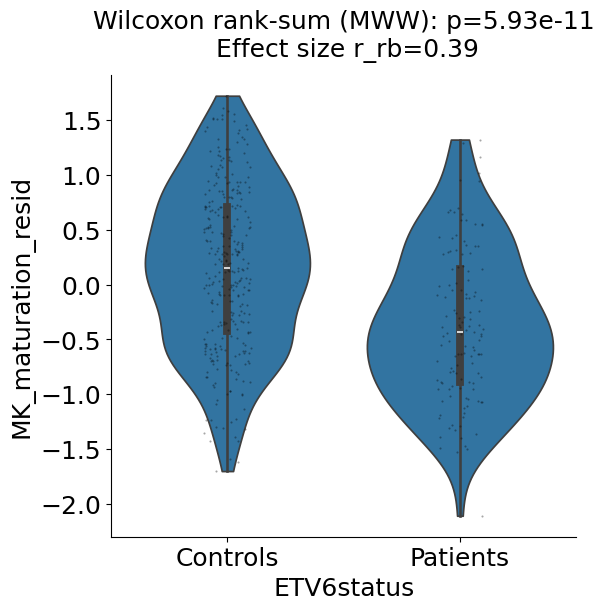

In [74]:
group_col = "ETV6status"     # "Controls" vs "Patients"

score_col = "MK_maturation_score"    # your module score in .obs

qc_covs = ["nCount_RNA", "nFeature_RNA", "percent.mt"]  # adjust if needed



# ---- Build dataframe ----
df = adata_etv6_megK_clean.obs[[group_col, score_col] + qc_covs].copy()
df[group_col] = df[group_col].astype(str)
df[score_col] = df[score_col].astype(float)
for c in qc_covs:
    df[c] = df[c].astype(float)

# ---- Residualize score_col on qc_covs (linear regression) ----
X = df[qc_covs].values
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)  # standardize covariates
X = np.column_stack([np.ones(X.shape[0]), X])      # intercept

y = df[score_col].values
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
df["MK_maturation_resid"] = y - (X @ beta)

# ---- Mann–Whitney U test (Wilcoxon rank-sum) ----
controls = df.loc[df[group_col] == "Controls", "MK_maturation_resid"].values
patients = df.loc[df[group_col] == "Patients", "MK_maturation_resid"].values
# two-sided test
u_stat, p_val = mannwhitneyu(controls, patients, alternative="two-sided")

# Effect size: rank-biserial correlation (equivalent to Cliff's delta for two groups)
n1, n2 = len(controls), len(patients)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)  # sign depends on ordering
# Make it "Patients higher is positive"
# If patients tend to be higher, U (controls vs patients) will be smaller and rank_biserial will be positive.
# If not, flip sign for interpretability:
if np.median(patients) < np.median(controls):
    rank_biserial *= -1

print(f"Mann–Whitney U (Wilcoxon rank-sum): U={u_stat:.1f}, p={p_val:.3e}")
print(f"Rank-biserial effect size (Patients higher positive): r_rb={rank_biserial:.3f}")
print(f"n Controls={n1}, n Patients={n2}")

# ---- Plot with annotation ----
plt.figure(figsize=(6, 6))
ax = sns.violinplot(data=df, x=group_col, y="MK_maturation_resid", cut=0, inner="box")
sns.stripplot(data=df, x=group_col, y="MK_maturation_resid", color="k", size=1.5, alpha=0.35)

# title = "MK_maturation residuals (MK_clean)\nregressed: " + ", ".join(qc_covs)
# ax.set_title(title)
ax.set_xlabel(group_col)
ax.set_ylabel("MK_maturation_resid")
    
# add p-value text
ymax = df["MK_maturation_resid"].max()
ymin = df["MK_maturation_resid"].min()
ypos = ymax + 0.08 * (ymax - ymin)

ax.text(
    0.5, ypos,
    f"Wilcoxon rank-sum (MWW): p={p_val:.2e}\n Effect size r_rb={rank_biserial:.2f}",
    ha="center", va="bottom"
)
plt.savefig(
    f'{res_dir}/etv6_mkmaturation_resid.pdf',
    dpi=300,
    bbox_inches='tight'
)

In [75]:
adata_etv6_megK.obs[["ETV6status", "HTO_maxID"]].value_counts()

ETV6status  HTO_maxID 
Controls    Ctrl1         674
            Ctrl2         427
Patients    P214.III.8    425
            F417.II.2     289
Name: count, dtype: int64

In [76]:
obs = adata_etv6_megK_clean.obs.copy()
obs["MK_maturation_resid"] = df["MK_maturation_resid"]
# keep only the columns we need, and force them to plain strings
tmp = obs[["ETV6status", "HTO_maxID", "MK_maturation_resid"]].copy()
tmp["ETV6status"] = tmp["ETV6status"].astype(str)
tmp["HTO_maxID"]  = tmp["HTO_maxID"].astype(str)

donor_df = (
    tmp.groupby(["ETV6status", "HTO_maxID"])["MK_maturation_resid"]
       .median()
       .reset_index(name="MK_maturation_resid_median")
)

donor_df


,ETV6status,HTO_maxID,MK_maturation_resid_median
0,Controls,Ctrl1,0.293428
1,Controls,Ctrl2,0.029261
2,Patients,F417.II.2,-0.383514
3,Patients,P214.III.8,-0.557459


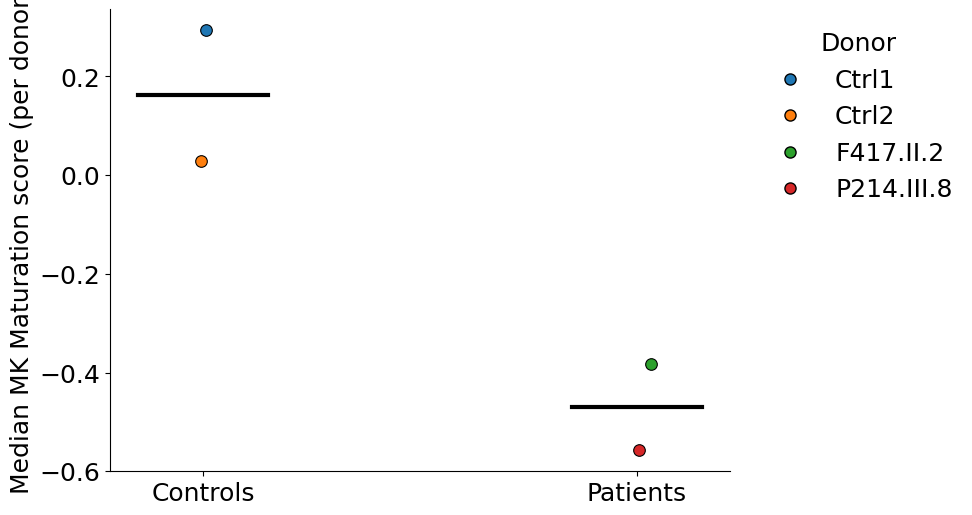

In [79]:
order = ["Controls", "Patients"]
xpos = {g:i for i,g in enumerate(order)}

# Make a fixed donor->color map (choose any colors you like)
donors = donor_df["HTO_maxID"].unique().tolist()
cmap = plt.get_cmap("tab10")
donor2color = {d: cmap(i % 10) for i, d in enumerate(donors)}

fig, ax = plt.subplots(figsize=(8,6))
rng = np.random.default_rng(0)

# plot donor dots + group mean lines
for g in order:
    dsub = donor_df[donor_df["ETV6status"] == g].copy()
    x = np.full(len(dsub), xpos[g], dtype=float) + rng.normal(0, 0.05, size=len(dsub))

    for xi, (_, r) in zip(x, dsub.iterrows()):
        ax.scatter(
            xi, r["MK_maturation_resid_median"],
            s=70,
            color=donor2color[r["HTO_maxID"]],
            edgecolor="black",
            linewidth=0.8,
            zorder=3,
        )

    # mean line of donor medians for the group (in neutral color)
    ymean = dsub["MK_maturation_resid_median"].mean()
    ax.plot([xpos[g]-0.15, xpos[g]+0.15], [ymean, ymean],
            lw=3, color="black", zorder=2)

# legend: create handles using the same donor2color map
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=donor2color[d],
               markeredgecolor='black', markersize=8, label=d)
    for d in donors
]
ax.legend(handles=handles, title="Donor", bbox_to_anchor=(1.02, 1),
          loc="upper left", frameon=False)

ax.set_xticks([xpos[g] for g in order])
ax.set_xticklabels(order)
ax.set_ylabel("Median MK Maturation score (per donor)")
ax.set_xlabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(
    f'{res_dir}/etv6_mkmaturation_repl.pdf',
    dpi=300,
    bbox_inches='tight'
)

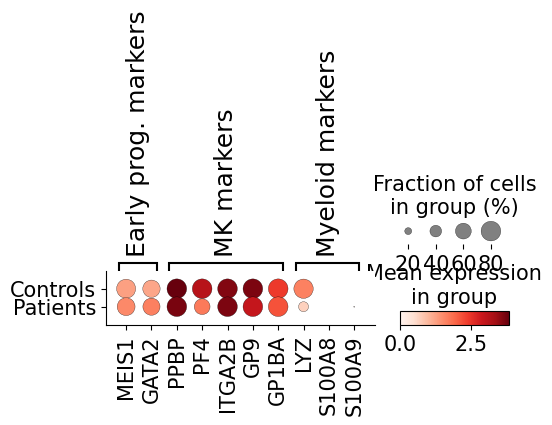

In [78]:
early_progenitor_markers = ["MEIS1","GATA2"]
late_mk_markers = ["PPBP", "PF4", "ITGA2B", "GP9", "GP1BA", ]
myeloid_markers = ["LYZ", "S100A8", "S100A9"]

sc.pl.dotplot(
    adata_etv6_megK_clean,
    var_names={
        "Early prog. markers": early_progenitor_markers,
        "MK markers": late_mk_markers,
        "Myeloid markers": myeloid_markers,
    },
    groupby="ETV6status",   # or omit groupby for single group
    dot_min=0.0,
    dot_max=0.8,
    show=False
)
plt.savefig(
    f'{res_dir}/etv6_marker_dotplot.pdf',
    dpi=300,
    bbox_inches='tight'
)